# Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget

In [2]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import logging
import tpvalidator.workspace as workspace
import tpvalidator.utils as utils
import tpvalidator.analyzers.snn as snn

from rich import print
from tpvalidator.utils import temporary_log_level, pandas_backend

In [3]:
import tpvalidator.datasetloader as dsl

with temporary_log_level(workspace.TriggerPrimitivesWorkspace._log, logging.INFO):
    datasets = dsl.load("data/vd/soa_trees")

INFO:TriggerPrimitivesWorkspace:tpmakerTPCSimpleThreshold__TriggerPrimitiveMaker found


Dataset 'eminus': 100 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

INFO:TriggerPrimitivesWorkspace:Opening Trigger NTuple file
INFO:TriggerPrimitivesWorkspace:Adding processing info
INFO:TriggerPrimitivesWorkspace:Adding 'event_summary' data
INFO:TriggerPrimitivesWorkspace:Adding 'mctruths' data
INFO:TriggerPrimitivesWorkspace:Adding 'mcneutrinos' data
INFO:TriggerPrimitivesWorkspace:Adding 'mcparticles' data
INFO:TriggerPrimitivesWorkspace:Adding 'simides' data
INFO:TriggerPrimitivesWorkspace:tpmakerTPCSimpleThreshold__TriggerPrimitiveMaker found


Dataset 'gammas': 100 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

INFO:TriggerPrimitivesWorkspace:Opening Trigger NTuple file
INFO:TriggerPrimitivesWorkspace:Adding processing info
INFO:TriggerPrimitivesWorkspace:Adding 'event_summary' data
INFO:TriggerPrimitivesWorkspace:Adding 'mctruths' data
INFO:TriggerPrimitivesWorkspace:Adding 'mcneutrinos' data
INFO:TriggerPrimitivesWorkspace:Adding 'mcparticles' data
INFO:TriggerPrimitivesWorkspace:Adding 'simides' data
INFO:TriggerPrimitivesWorkspace:tpmakerTPCSimpleThreshold__TriggerPrimitiveMaker found


Dataset 'radbkg': 100 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'mctruth_blockid_map': [
        [28, 'Rn220ChainFromPb212GenInUpperMesh1x8x6'],
        [27, 'CryostatNGammasAtLAr1x8x6'],
        [26, 'Kr85GenInLAr'],
        [25, 'U238ChainGenInAnode'],
        [24, 'K40GenInCathode'],
        [23, 'foamGammasAtLAr1x8x6'],
        [22, 'K42From42ArGenInUpperMesh1x8x6'],
        [21, 'Th232ChainGenInCathode'],
        [20, 'Rn222ChainRn222GenInLAr'],
        [19, 'U238ChainGenInCathode'],
        [18, 'K40GenInAnode'],
        [17, 'CavernwallNeutronsAtLAr1x8x6'],
        [16, 'Rn220ChainPb212GenInLAr'],
        [15, 'K42From42ArGenInLAr'],
        [14, 'Rn222ChainGenInPDS'],
        [13, 'Ar42GenInLAr'],
        [12, 'Rn222ChainFromBi210GenInUpperMesh1x8x6'],
        [11, 'Rn222ChainFromPo218GenInUpperMesh1x8x6'],
        [10, 'Rn222ChainPb210GenInLAr'],
        [9, 'Ar39GenInLAr'],
        [8, 'Rn222ChainPb214GenInLAr'],
        [7, 'Rn222ChainPo218GenInLAr'],
        [6, 'Rn222ChainFromPb214GenInUpperMesh1x8x6'],
        [5, 'Rn222ChainFromPb210GenInUpperMesh1x8x6'],
        [4, 'CavernwallGammasAtLAr1x8x6'],
        [3, 'Th232ChainGenInAnode'],
        [2, 'Rn222ChainFromBi214GenInUpperMesh1x8x6'],
        [1, 'Rn222ChainBi214GenInLAr'],
        [0, 'CavernNGammasAtLAr1x8x6']
    ],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [4]:
datasets.keys()

dict_keys(['eminus', 'gammas', 'radbkg'])

In [5]:
datasets['gammas'].tps.head()

event       run  subrun  version  flag  detid  channel  \
entry subentry                                                           
0     0             1  20000011       0        2     0      3      482   
      1             1  20000011       0        2     0      3      988   
      2             1  20000011       0        2     0      3     2140   
      3             1  20000011       0        2     0      3     2167   
      4             1  20000011       0        2     0      3     2764   

                samples_over_threshold  time_start  samples_to_peak  ...  \
entry subentry                                                       ...   
0     0                              1      180160                0  ...   
      1                              1      219104                0  ...   
      2                              1       95104                0  ...   
      3                              1       49184                0  ...   
      4                              1      122208                0  ...   

                   bt_z  bt_primary_x  bt_primary_y  bt_primary_z  \
entry subentry                                                      
0     0        -99999.0      -99999.0      -99999.0      -99999.0   
      1        -99999.0      -99999.0      -99999.0      -99999.0   
      2        -99999.0      -99999.0      -99999.0      -99999.0   
      3        -99999.0      -99999.0      -99999.0      -99999.0   
      4        -99999.0      -99999.0      -99999.0      -99999.0   

                bt_truth_block_id  bt_generator_name  time_peak  sample_start  \
entry subentry                                                                  
0     0                    -99999                        180160          5630   
      1                    -99999                        219104          6847   
      2                    -99999                         95104          2972   
      3                    -99999                         49184          1537   
      4                    -99999                        122208          3819   

                sample_peak  bt_is_signal  
entry subentry                             
0     0                5630             0  
      1                6847             0  
      2                2972             0  
      3                1537             0  
      4                3819             0  

[5 rows x 32 columns]

<Axes: xlabel='bt_primary_z', ylabel='bt_primary_y'>

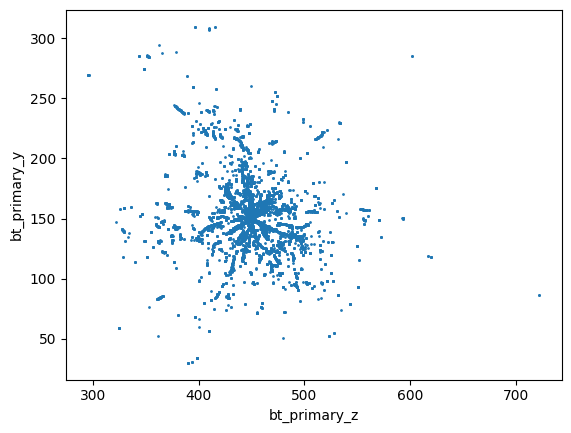

In [6]:
datasets['gammas'].tps.query('bt_is_signal == 1').plot.scatter(x='bt_primary_z', y='bt_primary_y', s=1)

<Axes: xlabel='bt_primary_x', ylabel='bt_primary_y'>

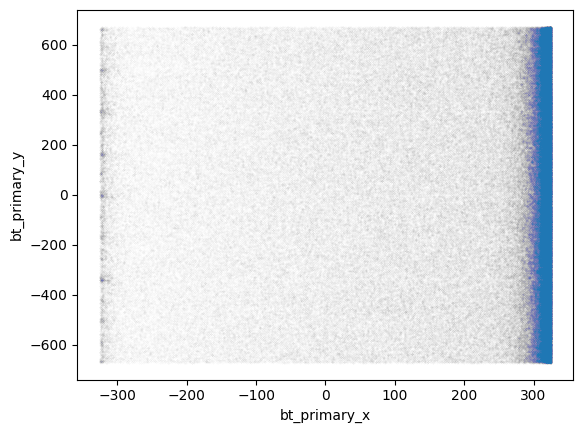

In [7]:
datasets['radbkg'].tps.query('bt_is_signal == 1').plot.scatter(x='bt_primary_x', y='bt_primary_y', s=0.1, alpha=0.01)